<a href="https://colab.research.google.com/github/Aysha2004/S7_INTERNSHIP/blob/main/Drowsiness_Detect_with_diff_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

found = None
print("Searching for your zip file...")
for root, dirs, files in os.walk("/content"):
    for fname in files:
        if fname.lower().endswith(".zip"):
            full_path = os.path.join(root, fname)
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            print(f"FOUND: {full_path}  ({size_mb:.1f} MB)")
            found = full_path

if found:
    ZIP_PATH = found
    print(f"\nUsing this file: {ZIP_PATH}")
else:
    print("\nNo zip file found. Did the upload finish? Check the Colab Files sidebar (folder icon on the left).")


Searching for your zip file...
FOUND: /content/archive (3).zip  (14.2 MB)

Using this file: /content/archive (3).zip


In [2]:
import zipfile
import os

zip_path = "/content/archive (3).zip"
extract_path = "/content/drowsy_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

for root, dirs, files in os.walk("/content/drowsy_dataset"):
    print(f"\nFolder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Number of Files: {len(files)}")


Folder: /content/drowsy_dataset
Subfolders: ['Drowsy_datset']
Number of Files: 0

Folder: /content/drowsy_dataset/Drowsy_datset
Subfolders: ['test', 'train']
Number of Files: 0

Folder: /content/drowsy_dataset/Drowsy_datset/test
Subfolders: ['DROWSY', 'NATURAL']
Number of Files: 0

Folder: /content/drowsy_dataset/Drowsy_datset/test/DROWSY
Subfolders: []
Number of Files: 757

Folder: /content/drowsy_dataset/Drowsy_datset/test/NATURAL
Subfolders: []
Number of Files: 726

Folder: /content/drowsy_dataset/Drowsy_datset/train
Subfolders: ['DROWSY', 'NATURAL']
Number of Files: 0

Folder: /content/drowsy_dataset/Drowsy_datset/train/DROWSY
Subfolders: []
Number of Files: 2809

Folder: /content/drowsy_dataset/Drowsy_datset/train/NATURAL
Subfolders: []
Number of Files: 3050


In [5]:
import os

train_path = "/content/drowsy_dataset/Drowsy_datset/train"
test_path = "/content/drowsy_dataset/Drowsy_datset/test"

print("TRAIN DATASET")

for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)

    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"{cls}: {count}")

print("\nTEST DATASET")

for cls in os.listdir(test_path):
    cls_path = os.path.join(test_path, cls)

    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"{cls}: {count}")

TRAIN DATASET
DROWSY: 2809
NATURAL: 3050

TEST DATASET
DROWSY: 757
NATURAL: 726


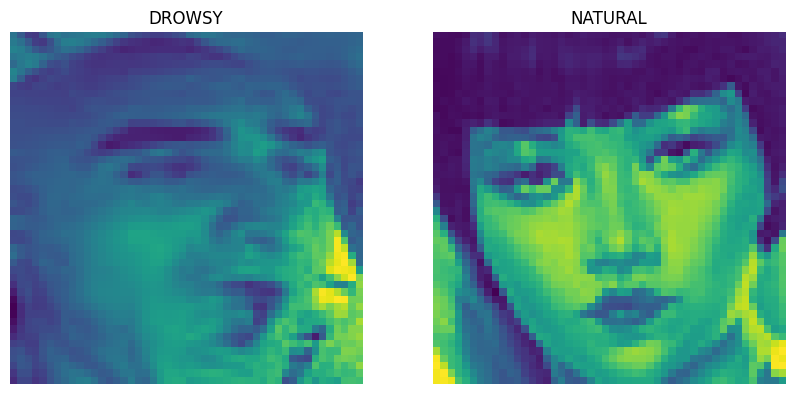

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random

classes = os.listdir(train_path)

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):

    img_path = os.path.join(
        train_path,
        cls,
        random.choice(os.listdir(os.path.join(train_path, cls)))
    )

    img = Image.open(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

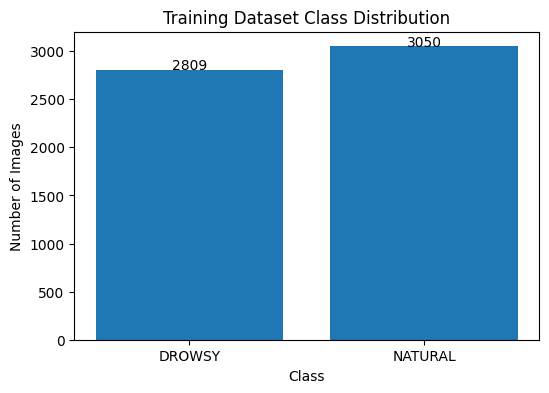

In [7]:
import matplotlib.pyplot as plt

train_counts = {
    "DROWSY": 2809,
    "NATURAL": 3050
}

plt.figure(figsize=(6,4))

plt.bar(
    train_counts.keys(),
    train_counts.values()
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, v in enumerate(train_counts.values()):
    plt.text(i, v, str(v), ha='center')

plt.show()

In [8]:
from PIL import Image
import os
import random

sizes = []

for cls in os.listdir(train_path):

    cls_path = os.path.join(train_path, cls)

    img_name = random.choice(os.listdir(cls_path))

    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)

    sizes.append(img.size)

print("Sample Image Sizes:")

for size in sizes:
    print(size)

Sample Image Sizes:
(48, 48)
(48, 48)


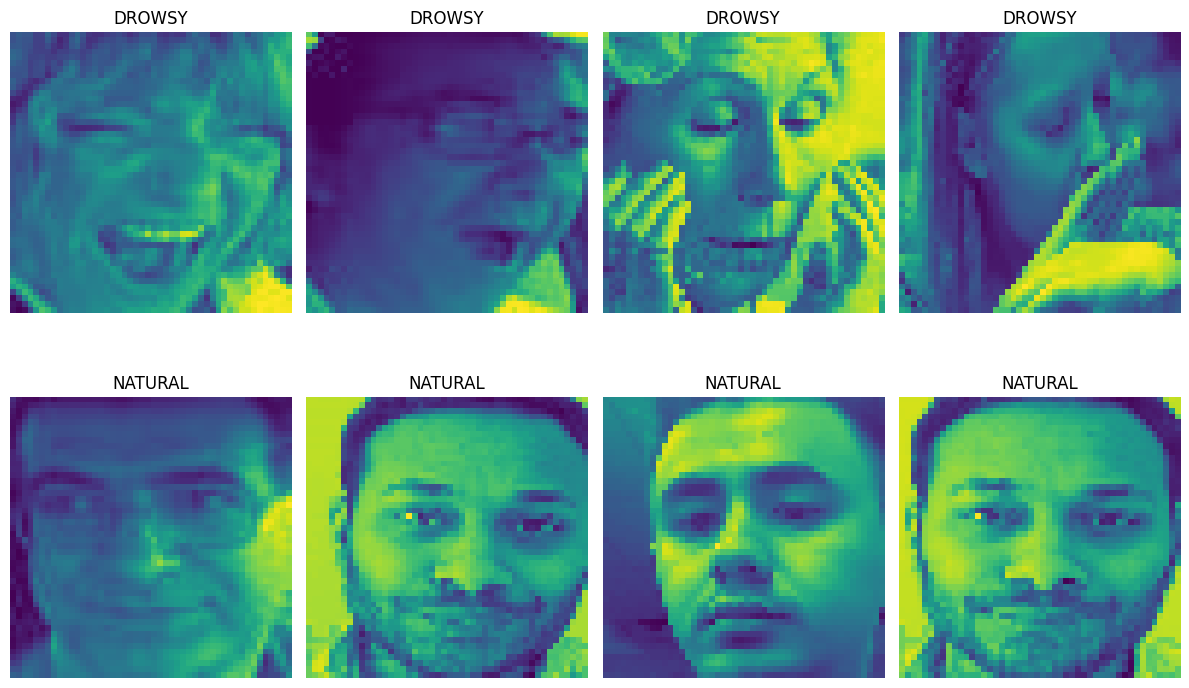

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

plt.figure(figsize=(12,8))

classes = os.listdir(train_path)

plot_num = 1

for cls in classes:

    cls_path = os.path.join(train_path, cls)

    sample_images = random.sample(
        os.listdir(cls_path),
        4
    )

    for img_name in sample_images:

        img_path = os.path.join(
            cls_path,
            img_name
        )

        img = Image.open(img_path)

        plt.subplot(2,4,plot_num)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

        plot_num += 1

plt.tight_layout()
plt.show()

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

# Test data (NO augmentation)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5859 images belonging to 2 classes.
Found 1483 images belonging to 2 classes.


In [11]:
print(train_generator.class_indices)

{'DROWSY': 0, 'NATURAL': 1}


In [12]:
X_batch, y_batch = next(train_generator)

print("Image Batch Shape:", X_batch.shape)
print("Label Batch Shape:", y_batch.shape)

print("\nFirst 10 Labels:")
print(y_batch[:10])

Image Batch Shape: (32, 48, 48, 3)
Label Batch Shape: (32,)

First 10 Labels:
[1. 1. 0. 1. 1. 0. 1. 1. 1. 0.]


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(48,48,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=3
)

Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.7867 - loss: 0.4470 - val_accuracy: 0.9434 - val_loss: 0.1576
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.8971 - loss: 0.2610 - val_accuracy: 0.9211 - val_loss: 0.1718
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - accuracy: 0.9240 - loss: 0.2048 - val_accuracy: 0.9589 - val_loss: 0.1022


In [16]:
test_loss, test_accuracy = cnn_model.evaluate(
    test_generator
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9589 - loss: 0.1022
Test Accuracy: 0.9588671326637268
Test Loss: 0.10223974287509918


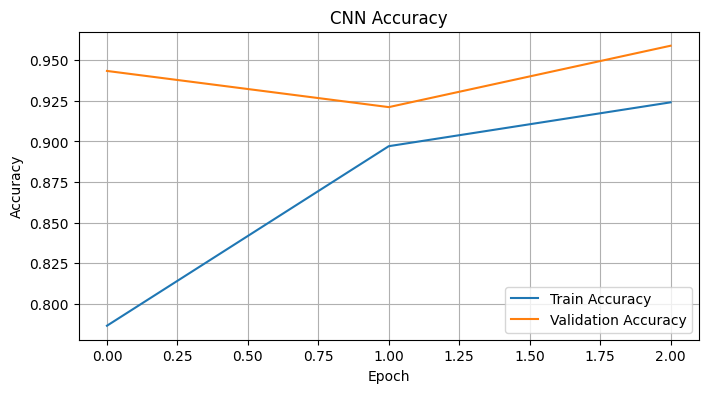

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

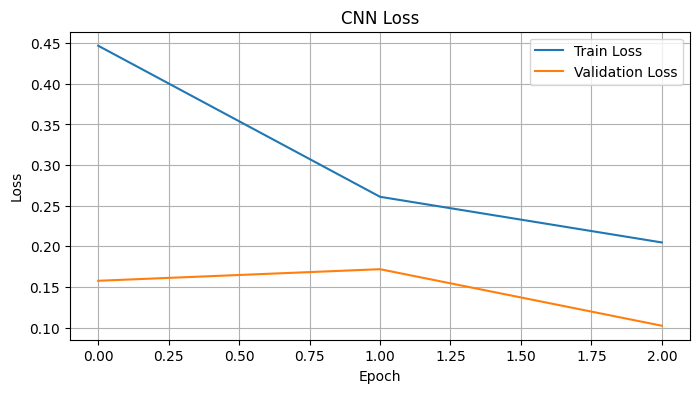

In [18]:
plt.figure(figsize=(8,4))

plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [19]:
import numpy as np

y_pred_probs = cnn_model.predict(test_generator)

y_pred = (y_pred_probs > 0.5).astype(int).flatten()

y_true = test_generator.classes

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    )
)

              precision    recall  f1-score   support

      DROWSY       1.00      0.92      0.96       757
     NATURAL       0.92      1.00      0.96       726

    accuracy                           0.96      1483
   macro avg       0.96      0.96      0.96      1483
weighted avg       0.96      0.96      0.96      1483



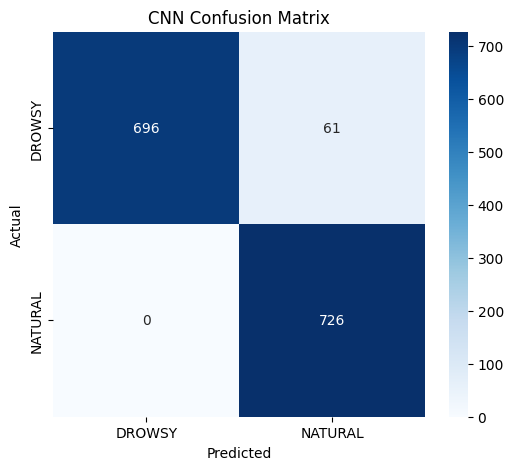

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

In [22]:
cnn_accuracy = history_cnn.history['val_accuracy'][-1]

print("CNN Validation Accuracy:", cnn_accuracy)

CNN Validation Accuracy: 0.9588671326637268


In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(48,48,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

mobilenet_model.summary()

/tmp/ipykernel_458/954213364.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=3
)

Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.8216 - loss: 0.4026 - val_accuracy: 0.9272 - val_loss: 0.1903
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.8696 - loss: 0.3004 - val_accuracy: 0.8860 - val_loss: 0.2711
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.8891 - loss: 0.2633 - val_accuracy: 0.9150 - val_loss: 0.2429


In [26]:
test_loss, test_accuracy = mobilenet_model.evaluate(
    test_generator
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9150 - loss: 0.2429
Test Accuracy: 0.9150370955467224
Test Loss: 0.24294613301753998


In [27]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_probs = mobilenet_model.predict(test_generator)

y_pred = (y_pred_probs > 0.5).astype(int).flatten()

y_true = test_generator.classes

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    )
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step
              precision    recall  f1-score   support

      DROWSY       0.97      0.86      0.91       757
     NATURAL       0.87      0.98      0.92       726

    accuracy                           0.92      1483
   macro avg       0.92      0.92      0.91      1483
weighted avg       0.92      0.92      0.91      1483



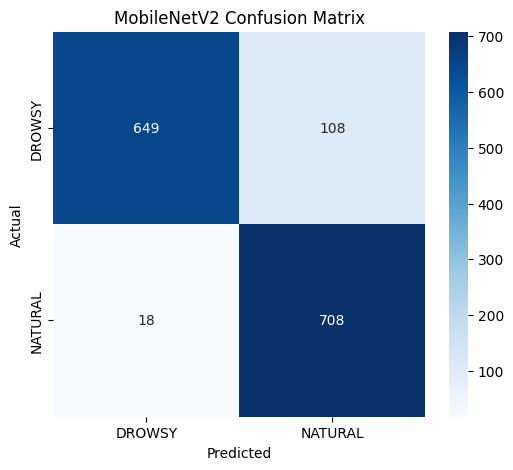

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

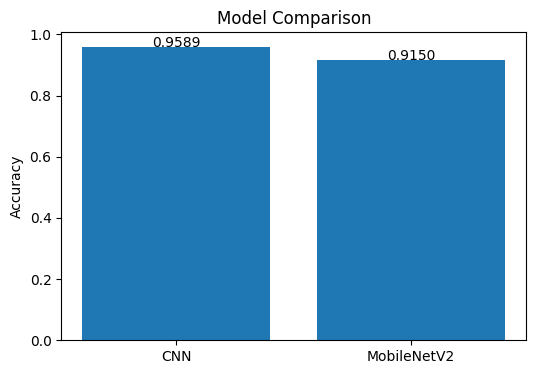

In [29]:
#Compare CNN vs MobileNetV2

import matplotlib.pyplot as plt

models = ["CNN", "MobileNetV2"]

accuracies = [
    cnn_accuracy,
    test_accuracy
]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.4f}", ha='center')

plt.show()

In [30]:
mobilenet_model.save("drowsiness_mobilenetv2.h5")

In [31]:
cnn_model.save("drowsiness_cnn.h5")

In [32]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.body.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());

      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [33]:
image_path = take_photo()

print("Image Saved:", image_path)

<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


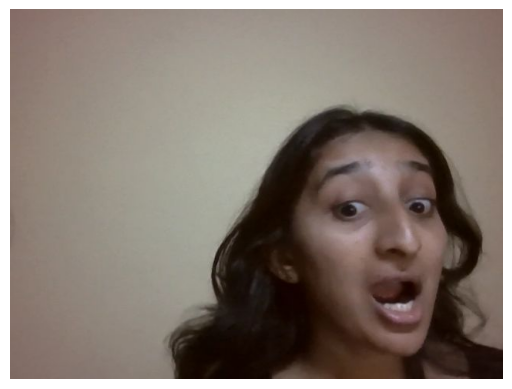

Prediction: DROWSY
Confidence: 57.24 %


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    image_path,
    target_size=(48,48)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

confidence = prediction[0][0]

plt.imshow(image.load_img(image_path))
plt.axis("off")
plt.show()

if confidence > 0.5:
    print("Prediction: NATURAL")
    print("Confidence:", round(confidence*100,2), "%")
else:
    print("Prediction: DROWSY")
    print("Confidence:", round((1-confidence)*100,2), "%")